# Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Upload Data and split X and Y

In [17]:
PATH = '../dataset/CaracteristicasExtraidasdeMascaras.xlsx'
df = pd.read_excel(PATH)

# Select only characteristics and labels
X = df[['Texture', 'Perimeter', 'Cx', 'Cy', 'Concave', 'Concave_Points', 'Smoothness']].values
y = df['Label'].values

In [18]:
X.shape, y.shape

((665, 7), (665,))

In [19]:
df.head()

,Mascara de donde se extraen características,Texture,Perimeter,Cx,Cy,Concave,Concave_Points,Smoothness,Label
0,1,120.465873,717.002087,127,117,1.090374,220,9,1
1,2,43.380253,193.539104,143,47,1.143877,64,8,1
2,3,60.315121,317.178713,127,69,1.216962,117,10,1
3,4,87.914507,560.173660,125,110,1.312826,191,8,1
4,5,84.541220,490.475175,106,136,1.210341,175,10,1


# Little Preproc

In [20]:
X_min = X.min(axis=0) # Normalziation Min-Max
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# Add Bias
X_norm = np.hstack([np.ones((X_norm.shape[0], 1)), X_norm])

X_norm.shape

(665, 8)

In [21]:
# Valid normalization
print("Min values after normalization:", X_norm.min(axis=0))
print("Max values after normalization:", X_norm.max(axis=0))
print("Min values before normalization:", X.min(axis=0))
print("Max values before normalization:", X.max(axis=0))

Min values after normalization: [1. 0. 0. 0. 0. 0. 0. 0.]
Max values after normalization: [1. 1. 1. 1. 1. 1. 1. 1.]
Min values before normalization: [11.54408454 43.5563488  24.         21.          1.00948973  5.
  4.        ]
Max values before normalization: [127.22755927 851.61225891 233.         170.           1.48216421
 307.          13.        ]


# Split data (Train, valid and test)

In [22]:
def split_stratified(X, y, train_p=0.7, valid_p=0.15, test_p=0.15):
    idx_0 = np.where(y == 0)[0] # search for benign samples
    idx_1 = np.where(y == 1)[0]# search for malignant samples
    
    # Shuffle indices to ensure randomness
    np.random.seed(42)
    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)
    
    # Calculate cut points for each class
    cut_train_0 = int(len(idx_0) * train_p)
    cut_valid_0 = int(len(idx_0) * (train_p + valid_p))
    
    # Calculate cut points for class 1
    cut_train_1 = int(len(idx_1) * train_p)
    cut_valid_1 = int(len(idx_1) * (train_p + valid_p))
    
    # Combine indices for train, valid, and test sets
    train_idx = np.concatenate([idx_0[:cut_train_0], idx_1[:cut_train_1]])
    valid_idx = np.concatenate([idx_0[cut_train_0:cut_valid_0], idx_1[cut_train_1:cut_valid_1]])
    test_idx = np.concatenate([idx_0[cut_valid_0:], idx_1[cut_valid_1:]])
    
    # Shuffle the combined indices to ensure randomness in the final splits
    np.random.shuffle(train_idx)
    np.random.shuffle(valid_idx)
    np.random.shuffle(test_idx)
    
    return train_idx, valid_idx, test_idx

train_idx, valid_idx, test_idx = split_stratified(X_norm, y)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_val,   y_val   = X_norm[valid_idx], y[valid_idx]
X_test,  y_test  = X_norm[test_idx],  y[test_idx]

# Valid balanced splits
print("Train set - Benign samples:", np.sum(y_train == 0), "Malignant samples:", np.sum(y_train == 1))
print("Validation set - Benign samples:", np.sum(y_val == 0), "Malignant samples:", np.sum(y_val == 1))
print("Test set - Benign samples:", np.sum(y_test == 0), "Malignant samples:", np.sum(y_test == 1))

Train set - Benign samples: 317 Malignant samples: 147
Validation set - Benign samples: 68 Malignant samples: 32
Test set - Benign samples: 69 Malignant samples: 32


# Train Loop and Auxiliar function

In [23]:
def train_perceptron(X_t, y_t, X_v, y_v, lr=0.01, epochs=100, use_pocket=True):
    mode = "POCKET" if use_pocket else "STANDARD"
    print(f"Starting {mode} Perceptron... LR: {lr}, Epochs: {epochs}")
    
    n_samples, n_features = X_t.shape
    weights = np.random.randn(n_features) * 0.01
    w_pocket = weights.copy()
    
    def get_f1_internal(X, y, w):
        preds = (np.dot(X, w) >= 0).astype(int)
        tp = np.sum((y == 1) & (preds == 1))
        fp = np.sum((y == 0) & (preds == 1))
        fn = np.sum((y == 1) & (preds == 0))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        return 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    best_f1 = get_f1_internal(X_t, y_t, w_pocket)
    train_history = [] 
    val_history = []   
    
    for epoch in range(epochs):
        error_acum_t = 0
        indices = np.random.permutation(n_samples)
        
        for i in indices:
            sum_lineal = np.dot(X_t[i], weights)
            y_pred = 1 if sum_lineal >= 0 else 0
            
            if y_t[i] != y_pred:
                weights += lr * (y_t[i] - y_pred) * X_t[i]
                
                # If using pocket, we check if these new weights are the best so far
                if use_pocket:
                    current_f1 = get_f1_internal(X_t, y_t, weights)
                    if current_f1 > best_f1:
                        w_pocket = weights.copy()
                        best_f1 = current_f1
            
            error_acum_t += (y_t[i] - y_pred)**2
            
        train_history.append(error_acum_t / n_samples)
        
        # Validation: use w_pocket if enabled, otherwise use current weights
        current_w = w_pocket if use_pocket else weights
        val_mse = np.mean((y_v - np.dot(X_v, current_w))**2)
        val_history.append(val_mse)
        
        print(f"Epoch {epoch+1}/{epochs} - Train MSE: {train_history[-1]:.4f} - Val MSE: {val_history[-1]:.4f}")

    # Final return: Pocket weights or the last weights calculated
    final_weights = w_pocket if use_pocket else weights
    return final_weights, train_history, val_history

def get_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def get_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1, recall, precision

# Loop to hyperparameters Analysis

Starting POCKET Perceptron... LR: 0.01, Epochs: 50
Epoch 1/50 - Train MSE: 0.1875 - Val MSE: 0.3083
Epoch 2/50 - Train MSE: 0.1315 - Val MSE: 0.3063
Epoch 3/50 - Train MSE: 0.1293 - Val MSE: 0.3063
Epoch 4/50 - Train MSE: 0.1142 - Val MSE: 0.2988
Epoch 5/50 - Train MSE: 0.0927 - Val MSE: 0.2988
Epoch 6/50 - Train MSE: 0.1013 - Val MSE: 0.2942
Epoch 7/50 - Train MSE: 0.1121 - Val MSE: 0.2969
Epoch 8/50 - Train MSE: 0.1185 - Val MSE: 0.2945
Epoch 9/50 - Train MSE: 0.1034 - Val MSE: 0.2945
Epoch 10/50 - Train MSE: 0.0970 - Val MSE: 0.2945
Epoch 11/50 - Train MSE: 0.0905 - Val MSE: 0.2945
Epoch 12/50 - Train MSE: 0.0862 - Val MSE: 0.2906
Epoch 13/50 - Train MSE: 0.0754 - Val MSE: 0.2906
Epoch 14/50 - Train MSE: 0.0948 - Val MSE: 0.2906
Epoch 15/50 - Train MSE: 0.0884 - Val MSE: 0.2906
Epoch 16/50 - Train MSE: 0.0905 - Val MSE: 0.2910
Epoch 17/50 - Train MSE: 0.0884 - Val MSE: 0.2910
Epoch 18/50 - Train MSE: 0.0970 - Val MSE: 0.2910
Epoch 19/50 - Train MSE: 0.1078 - Val MSE: 0.2881
Epoch 20

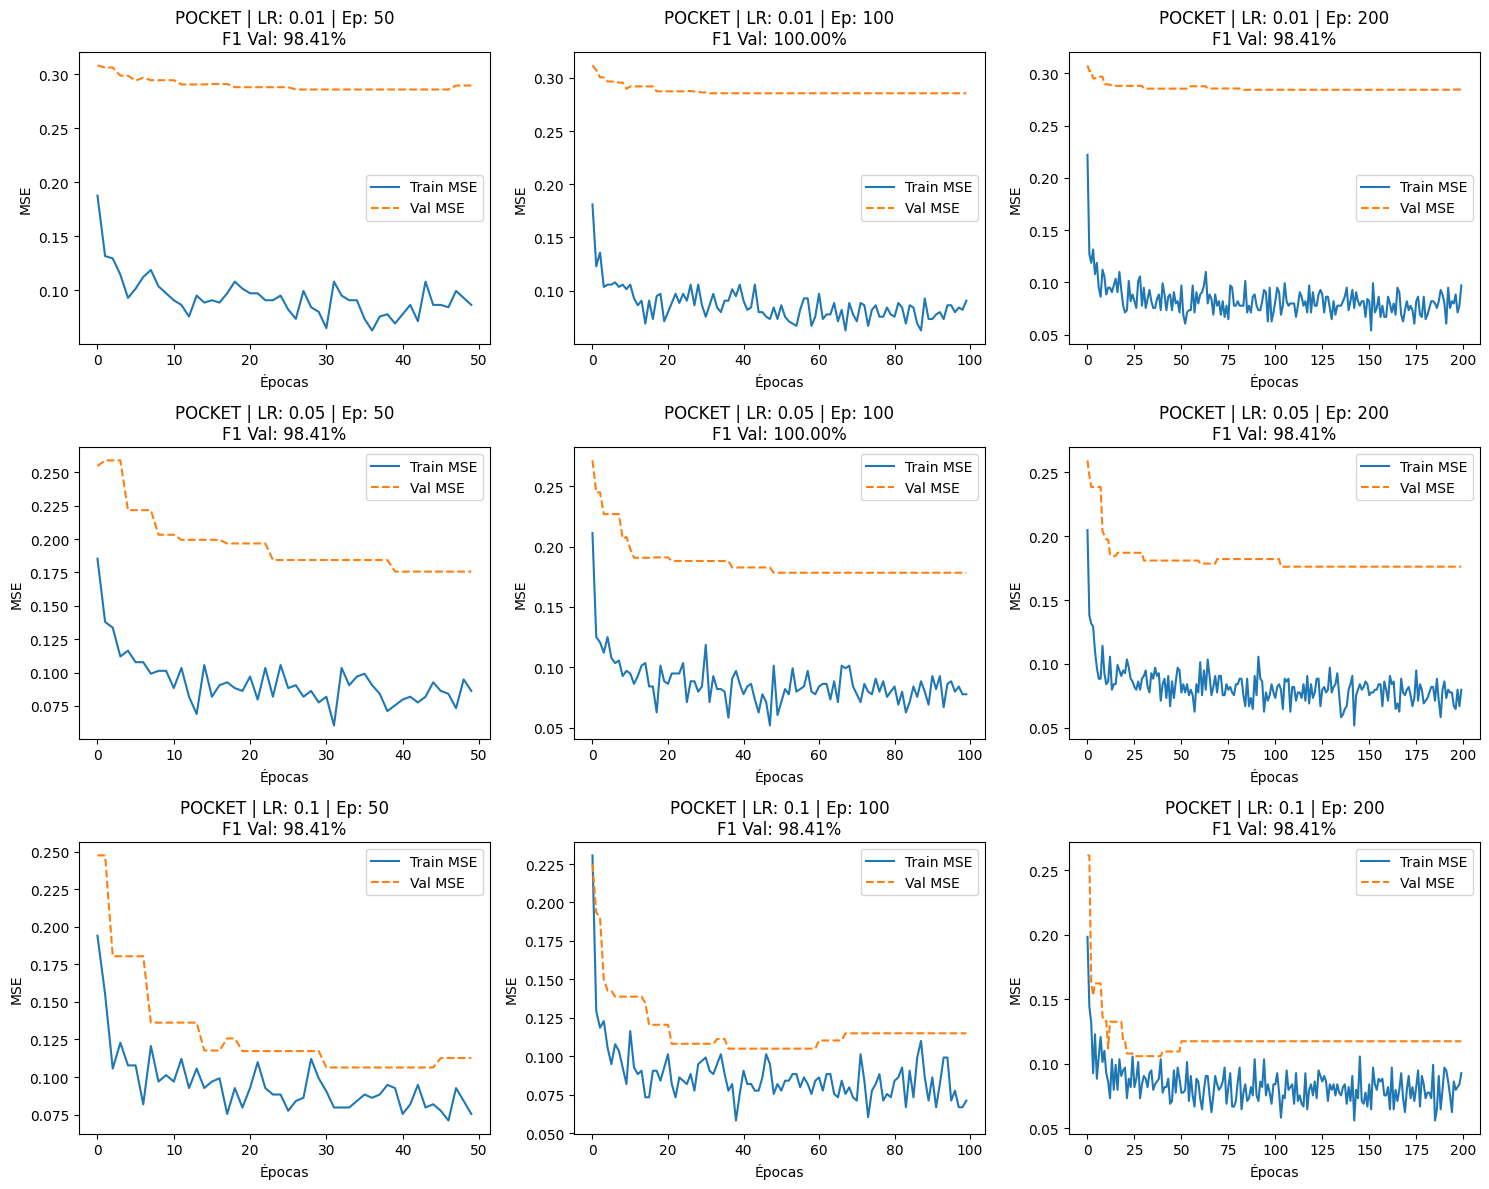

In [24]:
learning_rates = [0.01, 0.05, 0.1]
epochs_list = [50, 100, 200]
use_pocket_mode = True 

plt.figure(figsize=(15, 12))
plot_idx = 1


for lr in learning_rates:
    for epochs in epochs_list:

        start_time = time.time()
        w_final, h_train, h_val = train_perceptron(
            X_train, y_train, X_val, y_val, 
            lr=lr, epochs=epochs, use_pocket=use_pocket_mode
        )
        duration = time.time() - start_time
        
        y_train_pred = (np.dot(X_train, w_final) >= 0).astype(int)
        y_val_pred = (np.dot(X_val, w_final) >= 0).astype(int)
        
        f1_train, _, _ = get_metrics(y_train, y_train_pred)
        f1_val, recall_val, _ = get_metrics(y_val, y_val_pred)
        
        cm_val = get_confusion_matrix(y_val, y_val_pred)
        
        print(f"{'LR':<6} | {'Ep':<4} | {'Time(s)':<8} | {'F1 Train':<10} | {'F1 Val':<10}")
        print("-" * 75)
        print(f"{lr:<6} | {epochs:<4} | {duration:<8.4f} | {f1_train:<10.2%} | {f1_val:<10.2%}")
        
        mode = "POCKET" if use_pocket_mode else "STANDARD"

        plt.subplot(3, 3, plot_idx)
        plt.plot(h_train, label='Train MSE')
        plt.plot(h_val, label='Val MSE', linestyle='--')
        plt.title(f'{mode} | LR: {lr} | Ep: {epochs}\nF1 Val: {f1_val:.2%}')
        plt.xlabel('Épocas')
        plt.ylabel('MSE')
        plt.legend()
        plot_idx += 1

plt.tight_layout()
plt.show()

# Confusion matrix and results with test with POCKET

In [25]:
y_test_pred = (np.dot(X_test, w_final) >= 0).astype(int)

f1_test, recall_test, precision_test = get_metrics(y_test, y_test_pred)
acc_test = np.mean(y_test_pred == y_test)

cm_test = get_confusion_matrix(y_test, y_test_pred)

print("="*30)
print(" FINAL TEST EVALUATION ")
print("="*30)
print(f"F1-Score:  {f1_test:.4f}")
print(f"Recall:    {recall_test:.2%}")
print(f"Precision: {precision_test:.2%}")
print(f"Accuracy:  {acc_test:.2%}")
print("-" * 30)
print("Confusion Matrix (Test):")
print(cm_test)
print("="*30)

 FINAL TEST EVALUATION 
F1-Score:  0.9206
Recall:    90.62%
Precision: 93.55%
Accuracy:  95.05%
------------------------------
Confusion Matrix (Test):
[[67  2]
 [ 3 29]]


Starting STANDARD Perceptron... LR: 0.01, Epochs: 50
Epoch 1/50 - Train MSE: 0.2112 - Val MSE: 0.3127
Epoch 2/50 - Train MSE: 0.1638 - Val MSE: 0.2998
Epoch 3/50 - Train MSE: 0.1315 - Val MSE: 0.2985
Epoch 4/50 - Train MSE: 0.0927 - Val MSE: 0.2938
Epoch 5/50 - Train MSE: 0.0927 - Val MSE: 0.2982
Epoch 6/50 - Train MSE: 0.1034 - Val MSE: 0.3007
Epoch 7/50 - Train MSE: 0.1056 - Val MSE: 0.3104
Epoch 8/50 - Train MSE: 0.0991 - Val MSE: 0.3052
Epoch 9/50 - Train MSE: 0.0884 - Val MSE: 0.2848
Epoch 10/50 - Train MSE: 0.1034 - Val MSE: 0.2939
Epoch 11/50 - Train MSE: 0.0970 - Val MSE: 0.3034
Epoch 12/50 - Train MSE: 0.0927 - Val MSE: 0.2809
Epoch 13/50 - Train MSE: 0.0948 - Val MSE: 0.3057
Epoch 14/50 - Train MSE: 0.0797 - Val MSE: 0.2912
Epoch 15/50 - Train MSE: 0.1013 - Val MSE: 0.2810
Epoch 16/50 - Train MSE: 0.0948 - Val MSE: 0.3049
Epoch 17/50 - Train MSE: 0.1034 - Val MSE: 0.3043
Epoch 18/50 - Train MSE: 0.0884 - Val MSE: 0.2951
Epoch 19/50 - Train MSE: 0.0970 - Val MSE: 0.3017
Epoch 

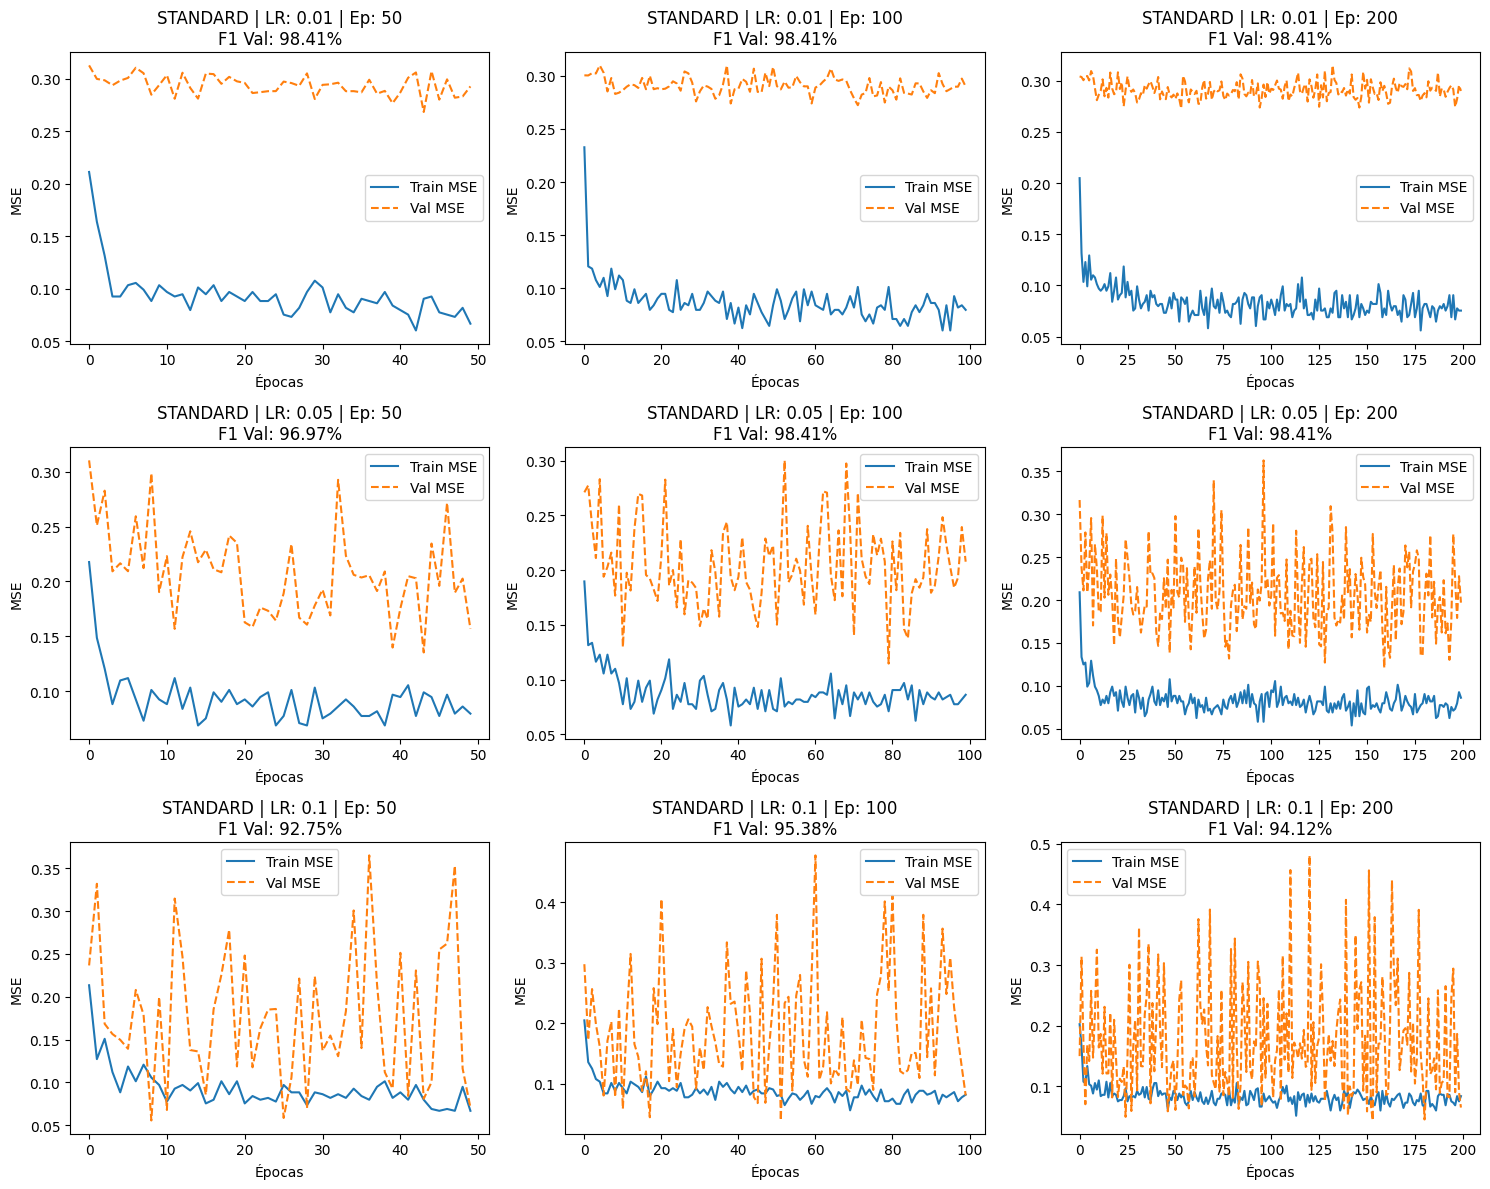

In [26]:
learning_rates = [0.01, 0.05, 0.1]
epochs_list = [50, 100, 200]
use_pocket_mode = False 

plt.figure(figsize=(15, 12))
plot_idx = 1


for lr in learning_rates:
    for epochs in epochs_list:

        start_time = time.time()
        w_final, h_train, h_val = train_perceptron(
            X_train, y_train, X_val, y_val, 
            lr=lr, epochs=epochs, use_pocket=use_pocket_mode
        )
        duration = time.time() - start_time
        
        y_train_pred = (np.dot(X_train, w_final) >= 0).astype(int)
        y_val_pred = (np.dot(X_val, w_final) >= 0).astype(int)
        
        f1_train, _, _ = get_metrics(y_train, y_train_pred)
        f1_val, recall_val, _ = get_metrics(y_val, y_val_pred)
        
        cm_val = get_confusion_matrix(y_val, y_val_pred)
        
        print(f"{'LR':<6} | {'Ep':<4} | {'Time(s)':<8} | {'F1 Train':<10} | {'F1 Val':<10}")
        print("-" * 75)
        print(f"{lr:<6} | {epochs:<4} | {duration:<8.4f} | {f1_train:<10.2%} | {f1_val:<10.2%}")
        
        mode = "POCKET" if use_pocket_mode else "STANDARD"

        plt.subplot(3, 3, plot_idx)
        plt.plot(h_train, label='Train MSE')
        plt.plot(h_val, label='Val MSE', linestyle='--')
        plt.title(f'{mode} | LR: {lr} | Ep: {epochs}\nF1 Val: {f1_val:.2%}')
        plt.xlabel('Épocas')
        plt.ylabel('MSE')
        plt.legend()
        plot_idx += 1

plt.tight_layout()
plt.show()

# Confusion matrix and results with test no POCKET

In [27]:
y_test_pred = (np.dot(X_test, w_final) >= 0).astype(int)

f1_test, recall_test, precision_test = get_metrics(y_test, y_test_pred)
acc_test = np.mean(y_test_pred == y_test)

cm_test = get_confusion_matrix(y_test, y_test_pred)

print("="*30)
print(" FINAL TEST EVALUATION ")
print("="*30)
print(f"F1-Score:  {f1_test:.4f}")
print(f"Recall:    {recall_test:.2%}")
print(f"Precision: {precision_test:.2%}")
print(f"Accuracy:  {acc_test:.2%}")
print("-" * 30)
print("Confusion Matrix (Test):")
print(cm_test)
print("="*30)

 FINAL TEST EVALUATION 
F1-Score:  0.8451
Recall:    93.75%
Precision: 76.92%
Accuracy:  89.11%
------------------------------
Confusion Matrix (Test):
[[60  9]
 [ 2 30]]


# Surface error

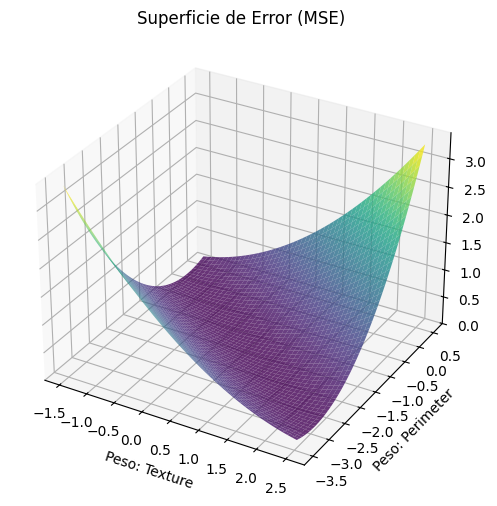

# Matrix Dispersion

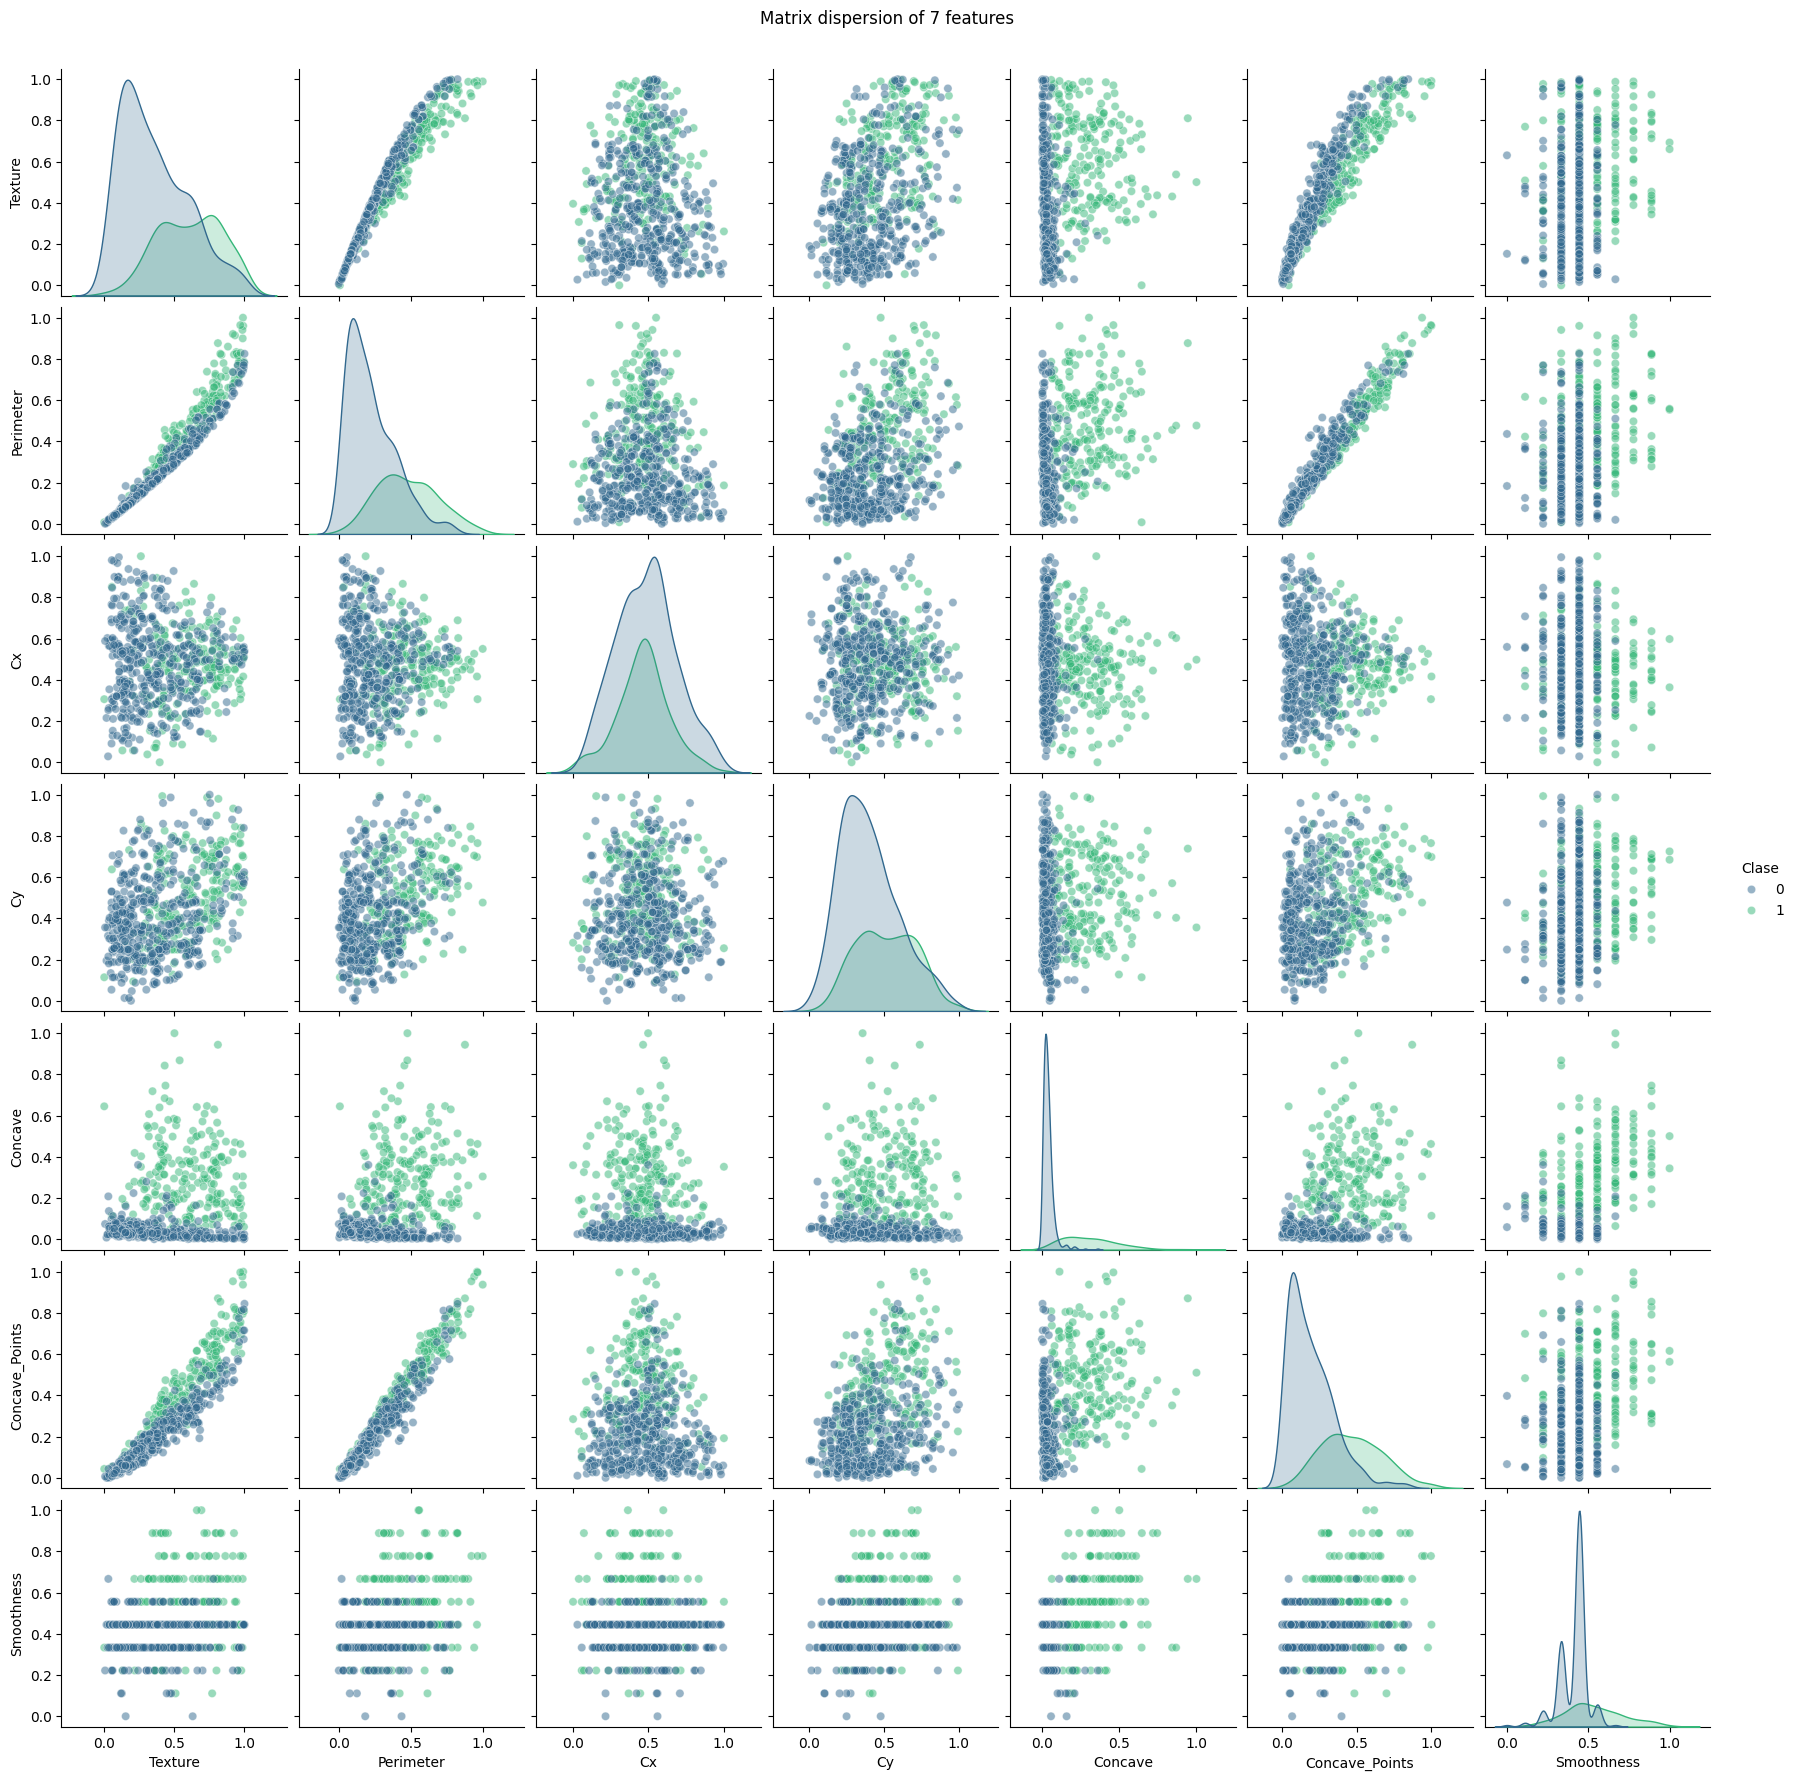

# Conclusions

- Superiority of the Pocket Method
By "freezing" the best weights found, the Pocket algorithm prevents 
final oscillations caused by data overlap, achieving F1=92.06% and 
Accuracy=95.05%, surpassing the standard Perceptron (F1=84.51%, 
Accuracy=89.11%) on the test set.

- Stability and Robustness
The standard Perceptron showed high sensitivity to hyperparameters 
(F1-Val ranging from 92.75% to 98.41%), while the Pocket version 
consistently achieved F1-Val ≥ 98.41% across all configurations, 
demonstrating superior robustness regardless of η or epochs chosen.

- Clinical Trade-off
The Pocket algorithm achieved a better Precision/Recall balance 
(93.55%/90.62%) versus the standard Perceptron (76.92%/93.75%), 
reducing false positives from 9 to 2 critical in avoiding 
unnecessary patient interventions.